In [ ]:
import numpy as np
xf_train = np.load("processed-imgs/xf_train.npy")
xf_test = np.load("processed-imgs/xf_test.npy")
y_train = np.load("processed-imgs/y_train.npy")
y_test = np.load("processed-imgs/y_test.npy")
xi_train = np.load("processed-imgs/xi_train.npy")
xi_test = np.load("processed-imgs/xi_test.npy")
x_train_scaled = np.load("processed-imgs/xf_train_scaled.npy")
x_test_scaled = np.load("processed-imgs/xf_test_scaled.npy")



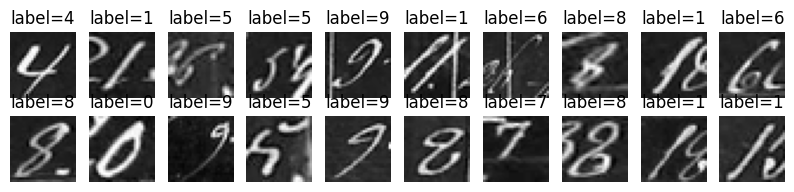

In [5]:
from plot_sample import plot_sample
plot_sample(xi_train, y_train)

In [6]:
from sklearn.linear_model._stochastic_gradient import SGDRegressor
from sklearn.model_selection import cross_val_score , KFold ,cross_validate
from sklearn.multiclass import OneVsRestClassifier
from time import time
lin_ova= OneVsRestClassifier(SGDRegressor(random_state=42))



In [7]:
help(OneVsRestClassifier)

Help on class OneVsRestClassifier in module sklearn.multiclass:

class OneVsRestClassifier(sklearn.base.MultiOutputMixin, sklearn.base.ClassifierMixin, sklearn.base.MetaEstimatorMixin, sklearn.base.BaseEstimator)
 |  OneVsRestClassifier(estimator, *, n_jobs=None, verbose=0)
 |
 |  One-vs-the-rest (OvR) multiclass strategy.
 |
 |  Also known as one-vs-all, this strategy consists in fitting one classifier
 |  per class. For each classifier, the class is fitted against all the other
 |  classes. In addition to its computational efficiency (only `n_classes`
 |  classifiers are needed), one advantage of this approach is its
 |  interpretability. Since each class is represented by one and one classifier
 |  only, it is possible to gain knowledge about the class by inspecting its
 |  corresponding classifier. This is the most commonly used strategy for
 |  multiclass classification and is a fair default choice.
 |
 |  OneVsRestClassifier can also be used for multilabel classification. To use


In [33]:
from sklearn.model_selection import GridSearchCV

param={
    'estimator__penalty' : ['l1' , 'l2' , None] ,
    'estimator__alpha' : [0.0001 , 0.001 , 0.01] , 
    'estimator__max_iter': [1000 , 1500 , 2000] , 
    'estimator__tol' : [1e-2 , 1e-3 , 1e-4],
    'estimator__learning_rate' :['constant'] ,
    'estimator__eta0' : [0.01 , 0.001 , 0.005 , 0.05] ,
    'estimator__early_stopping' : [True , False] 
}
grid = GridSearchCV(lin_ova , param ,cv=5 , verbose=1)
grid.fit(x_train_scaled , y_train )

Fitting 5 folds for each of 648 candidates, totalling 3240 fits


,estimator,OneVsRestClas...dom_state=42))
,param_grid,"{'estimator__alpha': [0.0001, 0.001, ...], 'estimator__early_stopping': [True, False], 'estimator__eta0': [0.01, 0.001, ...], 'estimator__learning_rate': ['constant'], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [34]:
grid.best_params_

{'estimator__alpha': 0.001,
 'estimator__early_stopping': False,
 'estimator__eta0': 0.001,
 'estimator__learning_rate': 'constant',
 'estimator__max_iter': 1000,
 'estimator__penalty': 'l1',
 'estimator__tol': 0.001}

In [ ]:
import joblib
joblib.dump(grid.best_estimator_ , 'best_sgdregressor.pkl')


In [37]:
import pandas as pd
grid_result = pd.DataFrame(grid.cv_results_)
grid_result = grid_result.sort_values(by='rank_test_score')
#cols = ['params' , 'mean_test_score' , 'std_test_score' , 'rank_test_score']
grid_result[:21].to_csv('grid_sgdregressor.csv',index=False) 

# will tune parameter manual also
## we could name the object vaiables same name (lin_ova) and overwrite , but to feel that it's new expe

#### big step size lr=0.01 , can overshoot!!

In [34]:
lin_ova1 = OneVsRestClassifier(SGDRegressor(random_state=42, alpha=0.001, eta0=0.01, learning_rate='constant', max_iter=2000,
             penalty='l1'))
lin_ova1.fit(x_train_scaled , y_train)
print(f"Train Accuracy : {lin_ova1.score(x_train_scaled , y_train)*100:.2f} % ")
print(f"Test Accuracy : {lin_ova1.score(x_test_scaled , y_test)*100:.2f} % ")

Train Accuracy : 8.99 % 
Test Accuracy : 8.00 % 


#### the previous expe goes very fast , make it slower 

In [35]:
lin_ova2 = OneVsRestClassifier(SGDRegressor(random_state=42, alpha=0.001, eta0=0.001, learning_rate='constant', max_iter=2000,
             penalty='l1'))
lin_ova2.fit(x_train_scaled , y_train)
print(f"Train Accuracy : {lin_ova2.score(x_train_scaled , y_train)*100:.2f} % ")
print(f"Test Accuracy : {lin_ova2.score(x_test_scaled , y_test)*100:.2f} % ")

Train Accuracy : 68.96 % 
Test Accuracy : 65.90 % 


#### still doing bad , slowly please

In [59]:
lin_ova3 = OneVsRestClassifier(SGDRegressor(random_state=42, alpha=0.001, eta0=0.0001, learning_rate='constant', max_iter=2000,
             penalty='l1'))
lin_ova3.fit(x_train_scaled , y_train)
print(f"Train Accuracy : {lin_ova3.score(x_train_scaled , y_train)*100:.2f} % ")
print(f"Test Accuracy : {lin_ova3.score(x_test_scaled , y_test)*100:.2f} % ")

Train Accuracy : 74.88 % 
Test Accuracy : 71.20 % 


#### good , reduce the penality , we want him to be more complex 

In [60]:
lin_ova4 = OneVsRestClassifier(SGDRegressor(random_state=42, alpha=0.0001, eta0=0.0001, learning_rate='constant', max_iter=2000,
             penalty='l1'))
lin_ova4.fit(x_train_scaled , y_train)
print(f"Train Accuracy : {lin_ova4.score(x_train_scaled , y_train)*100:.2f} % ")
print(f"Test Accuracy : {lin_ova4.score(x_test_scaled , y_test)*100:.2f} % ")

Train Accuracy : 75.19 % 
Test Accuracy : 70.50 % 


#### the penality didn't make him generlize , it is memorizing , increase penality , reduce lr

In [61]:
lin_ova5 = OneVsRestClassifier(SGDRegressor(random_state=42, alpha=0.001, eta0=0.00001, learning_rate='constant', max_iter=2000,
             penalty='l1'))
lin_ova5.fit(x_train_scaled , y_train)
print(f"Train Accuracy : {lin_ova5.score(x_train_scaled , y_train)*100:.2f} % ")
print(f"Test Accuracy : {lin_ova5.score(x_test_scaled , y_test)*100:.2f} % ")

Train Accuracy : 74.71 % 
Test Accuracy : 72.85 % 


#### that sounds great , let's compare with the grid search 

In [65]:
best_model=joblib.load('best_sgdregressor.pkl')
print(best_model.score(x_train_scaled , y_train)*100)
print(best_model.score(x_test_scaled , y_test)*100)


68.9625
65.9


In [62]:
help(SGDRegressor)

Help on class SGDRegressor in module sklearn.linear_model._stochastic_gradient:

class SGDRegressor(BaseSGDRegressor)
 |  SGDRegressor(loss='squared_error', *, penalty='l2', alpha=0.0001, l1_ratio=0.15, fit_intercept=True, max_iter=1000, tol=0.001, shuffle=True, verbose=0, epsilon=0.1, random_state=None, learning_rate='invscaling', eta0=0.01, power_t=0.25, early_stopping=False, validation_fraction=0.1, n_iter_no_change=5, warm_start=False, average=False)
 |
 |  Linear model fitted by minimizing a regularized empirical loss with SGD.
 |
 |  SGD stands for Stochastic Gradient Descent: the gradient of the loss is
 |  estimated each sample at a time and the model is updated along the way with
 |  a decreasing strength schedule (aka learning rate).
 |
 |  The regularizer is a penalty added to the loss function that shrinks model
 |  parameters towards the zero vector using either the squared euclidean norm
 |  L2 or the absolute norm L1 or a combination of both (Elastic Net). If the
 |  par

In [66]:
best_model.estimator

,loss,'squared_error'
,penalty,'l1'
,alpha,0.001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,42


## will agree on lin_ova5 , check generlization by cross validation 

In [67]:
start = time()
kf_scores=cross_validate(lin_ova5, x_train_scaled, y_train, cv=5, scoring='accuracy',return_train_score=True)
time_lin_ova_sgd_kf = time() - start
print(f"KFold Cross-validation train time: {time_lin_ova_sgd_kf:.2f} seconds")
print(f"KFold Cross-validation train Accuracy scores: {kf_scores['train_score']}")
print(f"KFold Cross-validation test Accuracy scores: {kf_scores['test_score']}")

KFold Cross-validation train time: 22.84 seconds
KFold Cross-validation train Accuracy scores: [0.75109375 0.74796875 0.75390625 0.74875    0.75375   ]
KFold Cross-validation test Accuracy scores: [0.7325   0.73375  0.713125 0.725625 0.72    ]


In [68]:
avg_kf_score_lin_ova_sgd_train = kf_scores['train_score'].mean()
print(f"Average KFold Cross-validation train Accuracy: {avg_kf_score_lin_ova_sgd_train:.4f}")
std_kf_score_lin_ova_sgd_train = kf_scores['train_score'].std()
print(f"Standard Deviation of KFold train  Cross-validation  Accuracy: {std_kf_score_lin_ova_sgd_train:.4f}")

avg_kf_score_lin_ova_sgd_test = kf_scores['test_score'].mean()
print(f"Average KFold Cross-validation test Accuracy: {avg_kf_score_lin_ova_sgd_test:.4f}")
std_kf_score_lin_ova_sgd_test = kf_scores['test_score'].std()
print(f"Standard Deviation of KFold test Cross-validation  Accuracy: {std_kf_score_lin_ova_sgd_test:.4f}")

Average KFold Cross-validation train Accuracy: 0.7511
Standard Deviation of KFold train  Cross-validation  Accuracy: 0.0025
Average KFold Cross-validation test Accuracy: 0.7250
Standard Deviation of KFold test Cross-validation  Accuracy: 0.0077


In [69]:
strart =time()
lin_ova5.fit(x_train_scaled, y_train)
time_lin_ova_sgd_kf += time()-start

In [70]:
y_test_pred = lin_ova5.predict(x_test_scaled)
y_train_pred = lin_ova5.predict(x_train_scaled)
y_test_pred

array([9, 7, 3, ..., 2, 4, 9], dtype=int64)

In [71]:
print(f"Linear Regressin SGD with OVA Train Accuracy: {lin_ova5.score(x_train_scaled, y_train):.4f}")

print(f"Linear Regressin SGD with OVA Test Accuracy: {lin_ova5.score(x_test_scaled, y_test):.4f}")

Linear Regressin SGD with OVA Train Accuracy: 0.7471
Linear Regressin SGD with OVA Test Accuracy: 0.7285


In [72]:
from cmetrics import *
accuracy_lin_ova_sgd = acc(y_test, y_test_pred)
print(f"LInear Regression SGD Accuracy: {accuracy_lin_ova_sgd:.4f}%")
prec_lin_ova_sgd = precision(y_test, y_test_pred)
print(f"LInear Regression SGD Precision: {prec_lin_ova_sgd:.4f}%")
rec_lin_ova_sgd = recall(y_test, y_test_pred)
print(f"LInear Regression SGD  Recall: {rec_lin_ova_sgd:.4f}%")
f1_score_lin_ova_sgd= f1(y_test, y_test_pred)
print(f"LInear Regression SGD F1 Score: {f1_score_lin_ova_sgd:.4f}%")

LInear Regression SGD Accuracy: 72.8500%
LInear Regression SGD Precision: 73.0676%
LInear Regression SGD  Recall: 72.8500%
LInear Regression SGD F1 Score: 72.6320%


In [73]:
import json

metrics = {
    "accuracy": accuracy_lin_ova_sgd,
    "precision": prec_lin_ova_sgd,
    "recall": rec_lin_ova_sgd,
    "f1_score": f1_score_lin_ova_sgd,
    "train_time": time_lin_ova_sgd_kf
}

with open("experiments/lin_ova_sgd.json", "w") as f:
    json.dump(metrics, f, indent=4)


In [74]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.74      0.81      0.77       200
           1       0.69      0.79      0.73       200
           2       0.81      0.74      0.78       200
           3       0.72      0.75      0.74       200
           4       0.71      0.73      0.72       200
           5       0.77      0.70      0.73       200
           6       0.77      0.86      0.81       200
           7       0.67      0.66      0.66       200
           8       0.75      0.52      0.61       200
           9       0.67      0.73      0.70       200

    accuracy                           0.73      2000
   macro avg       0.73      0.73      0.73      2000
weighted avg       0.73      0.73      0.73      2000



In [75]:
cm=conf_matrix(y_test, y_test_pred)
cm

array([[161,   7,   0,   6,   6,   3,   7,   2,   2,   6],
       [  5, 157,   5,   7,   4,   3,   3,   9,   5,   2],
       [  3,   5, 149,   9,   5,   3,   3,  10,   2,  11],
       [ 10,   5,   8, 150,  10,   2,   0,   4,   6,   5],
       [  6,  15,   2,   2, 147,   3,   9,   7,   4,   5],
       [ 10,   5,   2,   6,   2, 140,  17,   4,   7,   7],
       [  0,  13,   3,   1,   1,   8, 172,   0,   2,   0],
       [  2,  13,   6,   5,   5,   2,   2, 131,   7,  27],
       [ 10,   5,   3,  13,  17,  16,  11,  13, 104,   8],
       [ 10,   3,   5,   9,  10,   1,   0,  16,   0, 146]], dtype=int64)

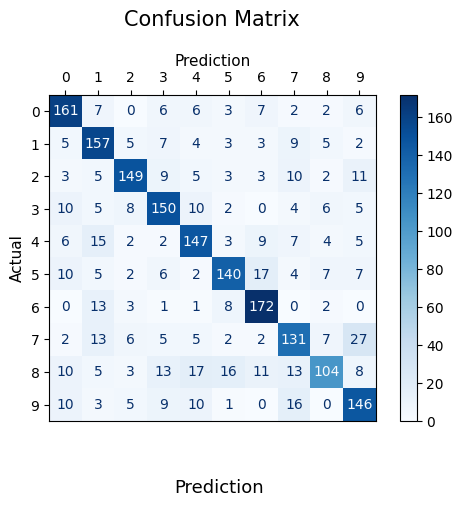

In [76]:
plot_confusion_matrix(cm)